In [5]:
# Подавление предупреждений
import warnings

for warn in [UserWarning, FutureWarning]:
    warnings.filterwarnings("ignore", category=warn)

# Импорт необходимых библиотек
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import polars as pl
import pandas as pd
import yfinance as yf
import sklearn
import networkx as nx
import jupyterlab as jlab
import ipywidgets
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# 0. Исходная реализация

[*********************100%***********************]  1 of 1 completed


Epoch 0, Loss: 0.000617
Epoch 10, Loss: 0.000232


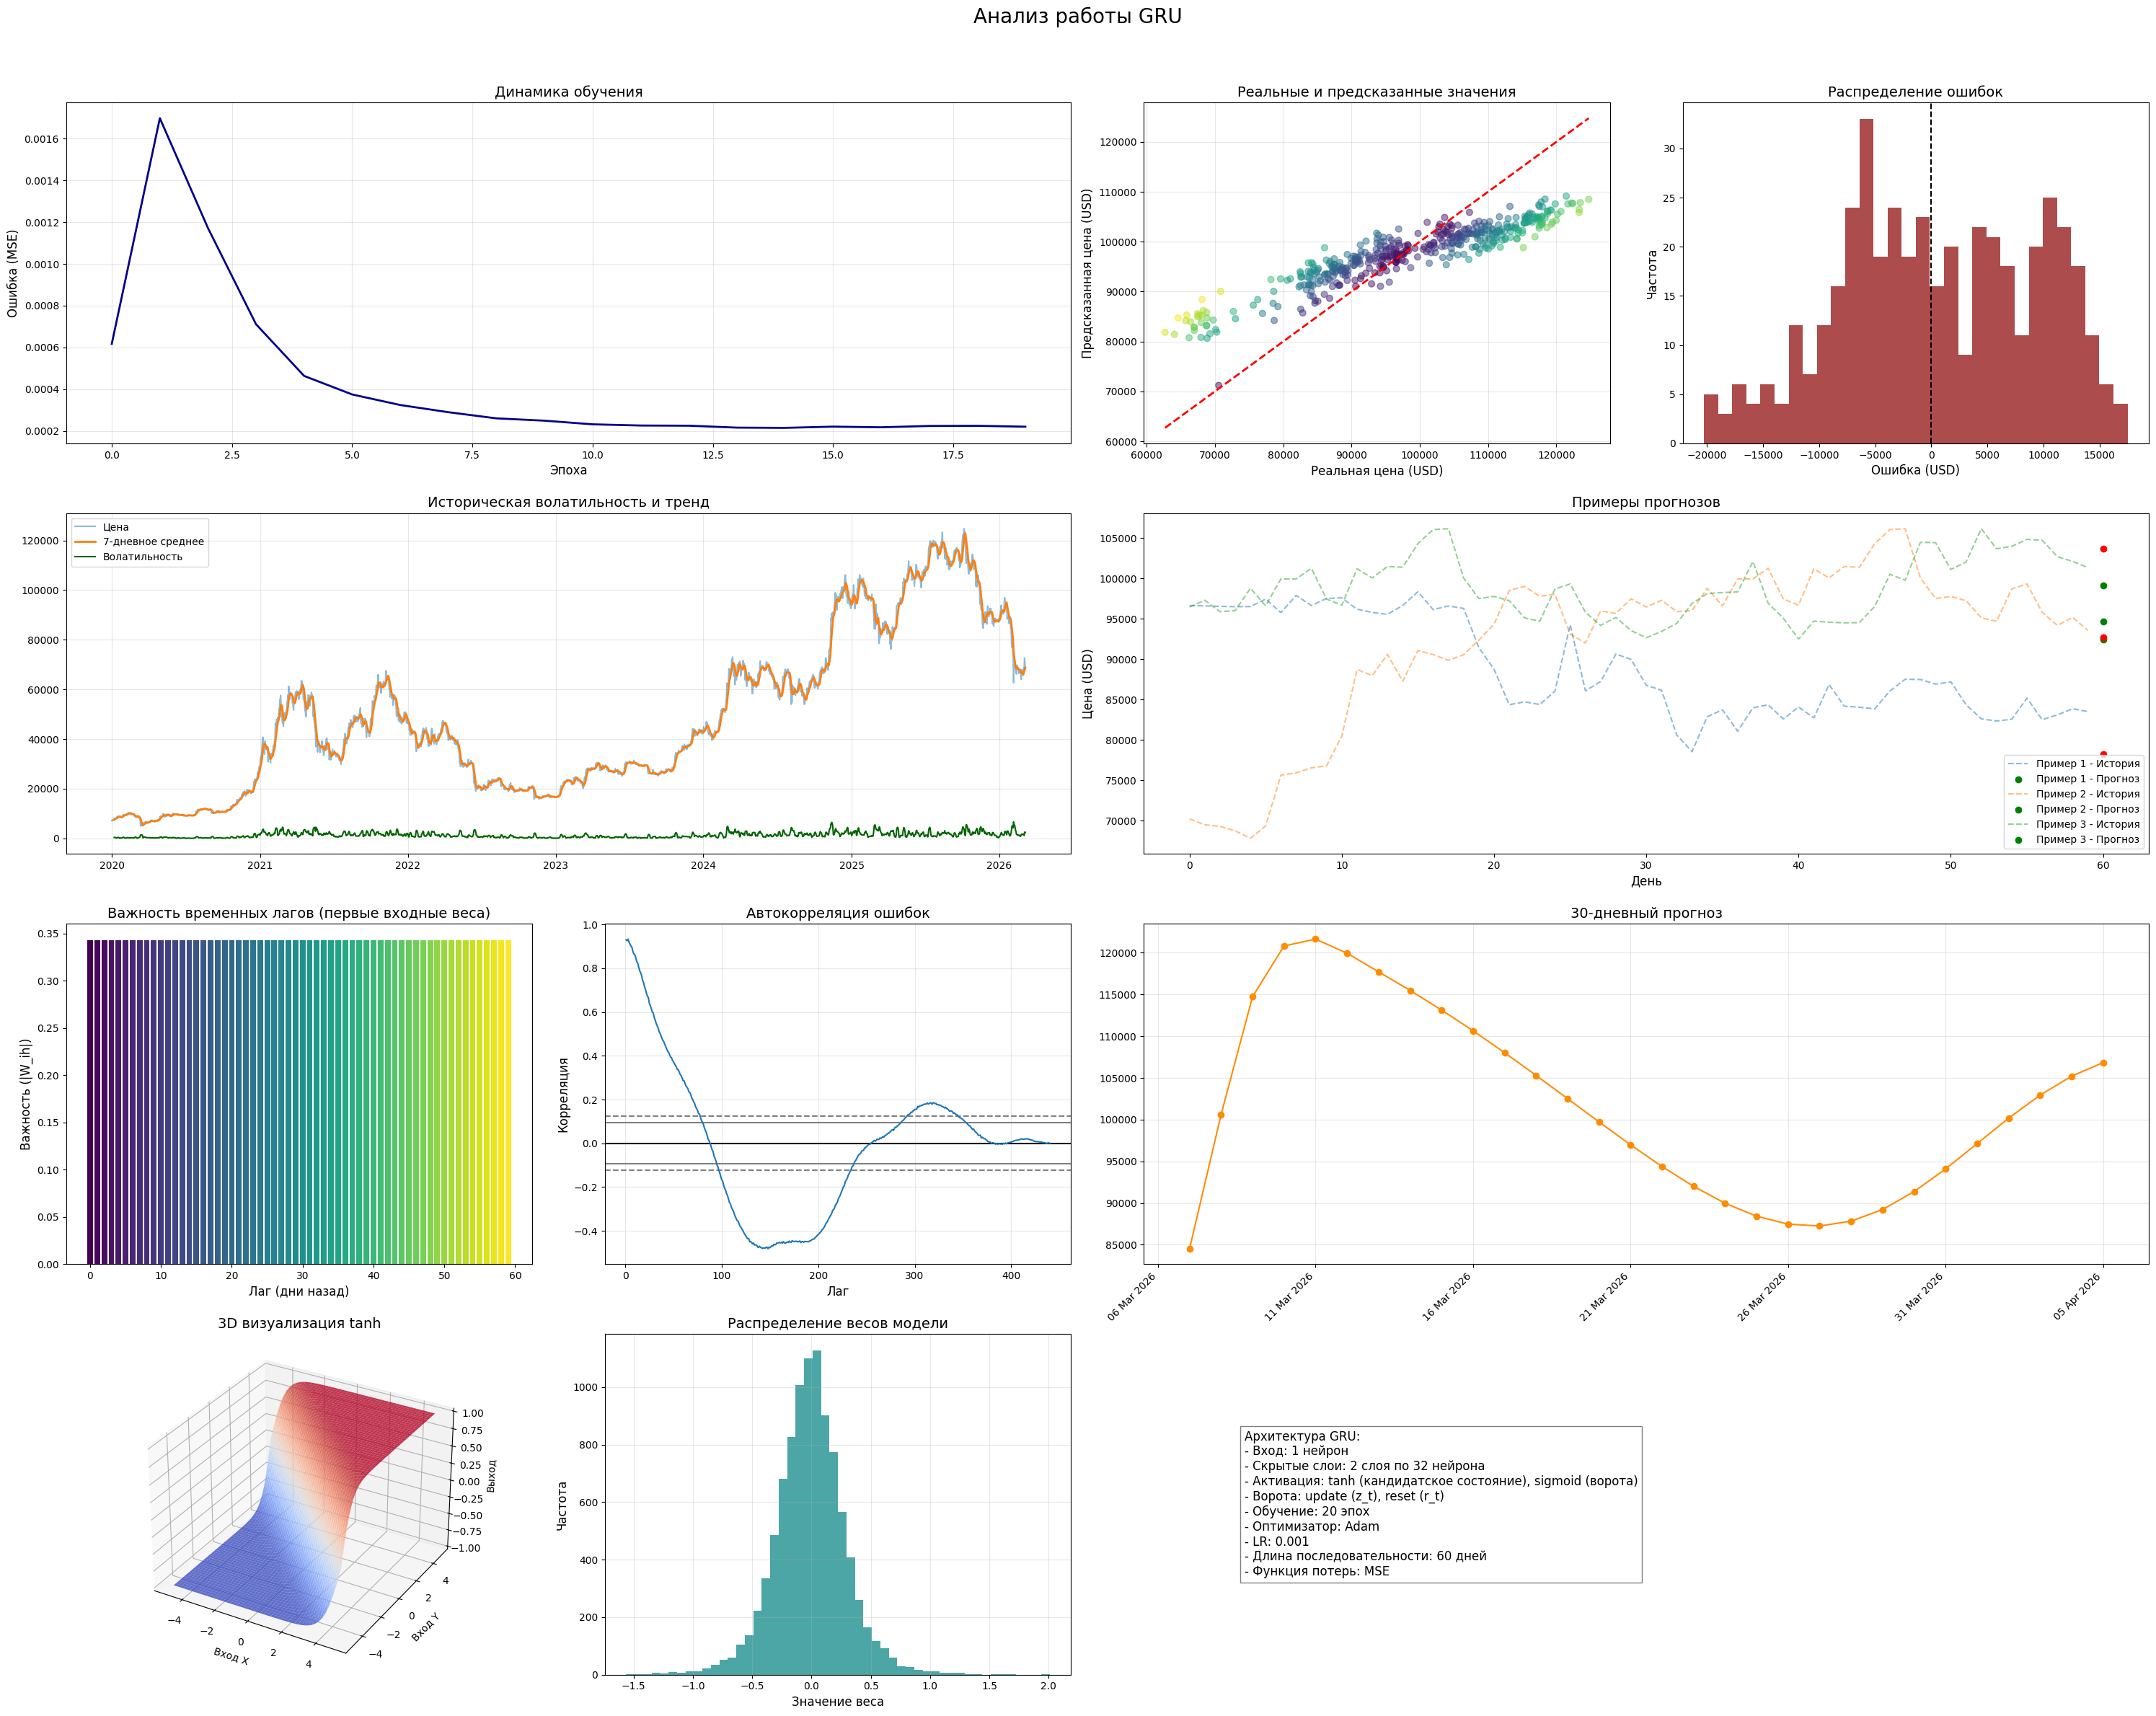

In [6]:
# Загрузка данных
ticker = "BTC-USD"
data = yf.download(
    ticker, start="2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d")
)
data = data[["Close"]]

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)


# Создание последовательностей
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length])
    return torch.FloatTensor(X), torch.FloatTensor(y)


seq_length = 60
X, y = create_sequences(scaled_data, seq_length)

# Разделение данных
train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


# Определение GRU модели
class BitcoinGRU(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(BitcoinGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, hn = self.gru(x, h0.detach())
        out = self.fc(out[:, -1, :])
        return out


# Инициализация модели
model = BitcoinGRU()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучение модели
num_epochs = 20
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0)
        target = y_train[i].unsqueeze(0)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(X_train)
    train_loss.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {avg_loss:.6f}")


# Прогнозирование
def forecast(model, sequence, days=30):
    current_seq = sequence.squeeze(0)
    predictions = []
    for _ in range(days):
        pred = model(current_seq.unsqueeze(0))
        predictions.append(pred.item())
        current_seq = torch.cat((current_seq[1:], pred))
    return predictions


# Генерация прогноза
last_sequence = scaled_data[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0)
scaled_forecast = forecast(model, input_tensor, days=30)
forecast_prices = scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1))

# Преобразование предсказаний и тестовых данных
model.eval()
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0))
        test_predictions.append(pred.item())

test_predictions = scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

# Создание единой фигуры с subplots
plt.figure(figsize=(30, 25))
plt.suptitle("Анализ работы GRU", y=0.95, fontsize=20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan=2)
ax1.plot(train_loss, color="darkblue", linewidth=2)
ax1.set_title("Динамика обучения", fontsize=14)
ax1.set_xlabel("Эпоха", fontsize=12)
ax1.set_ylabel("Ошибка (MSE)", fontsize=12)
ax1.grid(True, alpha=0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(
    y_test_original,
    test_predictions,
    alpha=0.5,
    c=np.abs(y_test_original - test_predictions),
    cmap="viridis",
    s=40,
)
ax2.plot(
    [y_test_original.min(), y_test_original.max()],
    [y_test_original.min(), y_test_original.max()],
    "--r",
    linewidth=2,
)
ax2.set_title("Реальные и предсказанные значения", fontsize=14)
ax2.set_xlabel("Реальная цена (USD)", fontsize=12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize=12)
ax2.grid(alpha=0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
errors = y_test_original - test_predictions
ax3.hist(errors, bins=30, color="darkred", alpha=0.7)
ax3.set_title("Распределение ошибок", fontsize=14)
ax3.set_xlabel("Ошибка (USD)", fontsize=12)
ax3.set_ylabel("Частота", fontsize=12)
ax3.axvline(x=0, color="black", linestyle="--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan=2)
window_size = 7
data["MA_7"] = data["Close"].rolling(window=window_size).mean()
data["Volatility"] = data["Close"].rolling(window=window_size).std()
ax4.plot(data["Close"], label="Цена", alpha=0.5)
ax4.plot(data["MA_7"], label="7-дневное среднее", linewidth=2)
ax4.plot(data["Volatility"], label="Волатильность", color="darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize=14)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan=2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0))
    real = scaler.inverse_transform(y_test[idx].numpy().reshape(-1, 1))

    ax5.plot(
        scaler.inverse_transform(seq),
        alpha=0.5,
        linestyle="--",
        label=f"Пример {i + 1} - История",
    )
    ax5.scatter(len(seq), real, color="red", zorder=5)
    ax5.scatter(
        len(seq),
        scaler.inverse_transform(pred.numpy()),
        color="green",
        zorder=5,
        label=f"Пример {i + 1} - Прогноз",
    )
ax5.set_title("Примеры прогнозов", fontsize=14)
ax5.set_xlabel("День", fontsize=12)
ax5.set_ylabel("Цена (USD)", fontsize=12)
ax5.legend()

# 6. Важность временных лагов (адаптированная для GRU)
ax6 = plt.subplot2grid((4, 4), (2, 0))
# Получаем веса входного слоя GRU
gru_weights = model.gru.weight_ih_l0.detach().numpy()
# Средние значения весов по всем нейронам
lag_importance = np.mean(np.abs(gru_weights[: model.hidden_size]), axis=0)
ax6.bar(
    range(seq_length),
    lag_importance[:seq_length],
    color=plt.cm.viridis(np.linspace(0, 1, seq_length)),
)
ax6.set_title("Важность временных лагов (первые входные веса)", fontsize=14)
ax6.set_xlabel("Лаг (дни назад)", fontsize=12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize=12)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax=ax7)
ax7.set_title("Автокорреляция ошибок", fontsize=14)
ax7.set_xlabel("Лаг", fontsize=12)
ax7.set_ylabel("Корреляция", fontsize=12)
ax7.grid(alpha=0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)
forecast_dates = pd.date_range(start=data.index[-1], periods=31)[1:]
ax8.plot(
    forecast_dates,
    forecast_prices,
    marker="o",
    markersize=6,
    linestyle="-",
    color="darkorange",
)
ax8.set_title("30-дневный прогноз", fontsize=14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(ax8.get_xticklabels(), rotation=45, ha="right")
ax8.grid(True, alpha=0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection="3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X, Y = np.meshgrid(x, y)
Z = np.tanh(X + Y)
ax9.plot_surface(X, Y, Z, cmap="coolwarm", alpha=0.8)
ax9.set_title("3D визуализация tanh", fontsize=14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().numpy().flatten())
ax10.hist(all_weights, bins=50, color="teal", alpha=0.7)
ax10.set_title("Распределение весов модели", fontsize=14)
ax10.set_xlabel("Значение веса", fontsize=12)
ax10.set_ylabel("Частота", fontsize=12)
ax10.grid(True, alpha=0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan=2)
ax11.axis("off")
text = """Архитектура GRU:
- Вход: 1 нейрон
- Скрытые слои: 2 слоя по 32 нейрона
- Активация: tanh (кандидатское состояние), sigmoid (ворота)
- Ворота: update (z_t), reset (r_t)
- Обучение: 20 эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 60 дней
- Функция потерь: MSE"""
ax11.text(
    0.1, 0.5, text, fontsize=12, va="center", bbox=dict(facecolor="white", alpha=0.5)
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## Выводы по исходной реализации

### Что хорошо:
- Обучение сходится, но слишком резко
- Веса распределены похожим образом на нормальное распределение

### Что плохо:
- Обучение сходится, но слишком резко
- Предсказания не лежат на диагонали
- Модель предсказывает константу на 30 дневном прогнозе, так как накапливается ошибка
- Модель пропускает важные временные паттерны
- Используется только 1 признак
- MinMaxScaler(0,1) не учитывает будущие экстремумы
- Всего 20 эпох - возможно недообучение
- 32 нейрона могут быть недостаточны для сложных паттернов

# 1. Добавление признаков

Исходная модель использовала только Close. Надо добвить технические индикаторы

In [7]:
# Загрузка данных с расширенными признаками
ticker = "BTC-USD"
data = yf.download(ticker, start="2020-01-01", end=pd.Timestamp.now().strftime("%Y-%m-%d"))

if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.droplevel(1)

# Создание дополнительных технических признаков
data['Returns'] = data['Close'].pct_change()
data['High_Low'] = data['High'] - data['Low']
data['Price_Range'] = (data['High'] - data['Low']) / data['Close']

# Скользящие средние
data['MA7'] = data['Close'].rolling(window=7).mean()
data['MA21'] = data['Close'].rolling(window=21).mean()
data['MA50'] = data['Close'].rolling(window=50).mean()

# Волатильность
data['Volatility'] = data['Returns'].rolling(window=21).std()

# RSI
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

data['RSI'] = calculate_rsi(data['Close'])

# MACD
exp1 = data['Close'].ewm(span=12, adjust=False).mean()
exp2 = data['Close'].ewm(span=26, adjust=False).mean()
data['MACD'] = exp1 - exp2
data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()

# Объем торгов (нормализованный)
data['Volume_MA'] = data['Volume'].rolling(window=21).mean()
data['Volume_Ratio'] = data['Volume'] / data['Volume_MA']

data = data.dropna()
feature_columns = ['Close', 'Open', 'High', 'Low', 'Volume', 
                   'Returns', 'High_Low', 'Price_Range',
                   'MA7', 'MA21', 'MA50', 'Volatility', 
                   'RSI', 'MACD', 'Signal_Line', 'Volume_Ratio']

features = data[feature_columns].values

# Нормализация данных
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler.fit_transform(features)

# Сохранение scaler для Close отдельно
close_scaler = MinMaxScaler(feature_range=(0, 1))
close_scaler.fit(data[['Close']].values)

print(f"Загружено {len(data)} записей")
print(f"Количество признаков: {len(feature_columns)}")
print(f"Период данных: с {data.index[0]} по {data.index[-1]}")
print()
print(f"Первые несколько строк признаков:")
print(data[feature_columns].head())

[*********************100%***********************]  1 of 1 completed

Загружено 2208 записей
Количество признаков: 16
Период данных: с 2020-02-19 00:00:00 по 2026-03-06 00:00:00

Первые несколько строк признаков:
Price             Close          Open          High          Low       Volume  \
Date                                                                            
2020-02-19  9633.386719  10143.798828  10191.675781  9611.223633  46992019710   
2020-02-20  9608.475586   9629.325195   9643.216797  9507.900391  44925260237   
2020-02-21  9686.441406   9611.782227   9723.014648  9589.743164  40930547513   
2020-02-22  9663.181641   9687.707031   9698.231445  9600.728516  35838025154   
2020-02-23  9924.515625   9663.318359   9937.404297  9657.791016  41185185761   

Price        Returns    High_Low  Price_Range          MA7         MA21  \
Date                                                                      
2020-02-19 -0.050149  580.452148     0.060254  9973.697126  9780.904343   
2020-02-20 -0.002586  135.316406     0.014083  9887.139369  9785

In [8]:
# Создание последовательностей с несколькими признаками
def create_sequences_multivariate(data, seq_length, target_idx=0):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length, target_idx])  # предсказание только Close
    return torch.FloatTensor(X), torch.FloatTensor(y)
seq_length = 60 

# Создание последовательностей
X, y = create_sequences_multivariate(scaled_features, seq_length, target_idx=0)

# Разделение на train/test (80/20)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Форма входных данных: (batch_size, seq_length={seq_length}, n_features={X_train.shape[2]})")
print(f"Форма целевых данных: (batch_size, 1)")

Размер обучающей выборки: torch.Size([1718, 60, 16])
Размер тестовой выборки: torch.Size([430, 60, 16])
Форма входных данных: (batch_size, seq_length=60, n_features=16)
Форма целевых данных: (batch_size, 1)


# 2. Улучшение модели

- input_size=1 -> input_size=16 (количество признаков)
- hidden_size=32 -> hidden_size=64
- Dropout для регуляризации
- num_epochs=20 -> num_epochs=50

In [9]:
class BitcoinGRU(nn.Module):
    def __init__(self, input_size=16, hidden_size=64, num_layers=2):
        super(BitcoinGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0  # добавлен Dropout
        )
        self.dropout = nn.Dropout(0.2)
        self.fc = nn.Linear(hidden_size, 1)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).requires_grad_()
        out, hn = self.gru(x, h0.detach())
        out = self.dropout(out[:, -1, :])
        out = self.fc(out)
        return out

# Инициализация модели
model = BitcoinGRU()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [10]:
# Обучение модели 
num_epochs = 50
train_loss = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for i in range(len(X_train)):
        inputs = X_train[i].unsqueeze(0)
        target = y_train[i].unsqueeze(0)
        
        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    avg_loss = total_loss/ len(X_train)
    train_loss.append(avg_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss:.6f}')

Epoch 0, Loss: 0.001662
Epoch 10, Loss: 0.000778
Epoch 20, Loss: 0.000669
Epoch 30, Loss: 0.000581
Epoch 40, Loss: 0.000554


In [11]:
# Прогнозирование 
def forecast(model, sequence, days=30):
    current_seq = sequence.squeeze(0)
    predictions = []
    for i in range(days):
        pred = model(current_seq.unsqueeze(0))
        predictions.append(pred.item())
        new_row = current_seq[-1].clone()
        new_row[0] = pred.item()
        current_seq = torch.cat((current_seq[1:], new_row.unsqueeze(0)))
    return predictions

# Генерация прогноза
last_sequence = scaled_features[-seq_length:] 
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0)
scaled_forecast = forecast(model, input_tensor, days=30)
forecast_prices = close_scaler.inverse_transform(np.array(scaled_forecast).reshape(-1, 1)) 

# Преобразование предсказаний и тестовых данных
model.eval()
test_predictions = []
with torch.no_grad():
    for seq in X_test:
        pred = model(seq.unsqueeze(0))
        test_predictions.append(pred.item())

# Обратная трансформация для close_scaler
test_predictions_transformed = close_scaler.inverse_transform(np.array(test_predictions).reshape(-1, 1))
y_test_original = close_scaler.inverse_transform(y_test.numpy().reshape(-1, 1))

print(f"Последняя реальная цена: ${data['Close'].iloc[-1]:.2f}")
print(f"Прогноз на завтра: ${forecast_prices[0][0]:.2f}")
print(f"Прогноз через 30 дней: ${forecast_prices[-1][0]:.2f}")

Последняя реальная цена: $68136.49
Прогноз на завтра: $83249.57
Прогноз через 30 дней: $77706.42


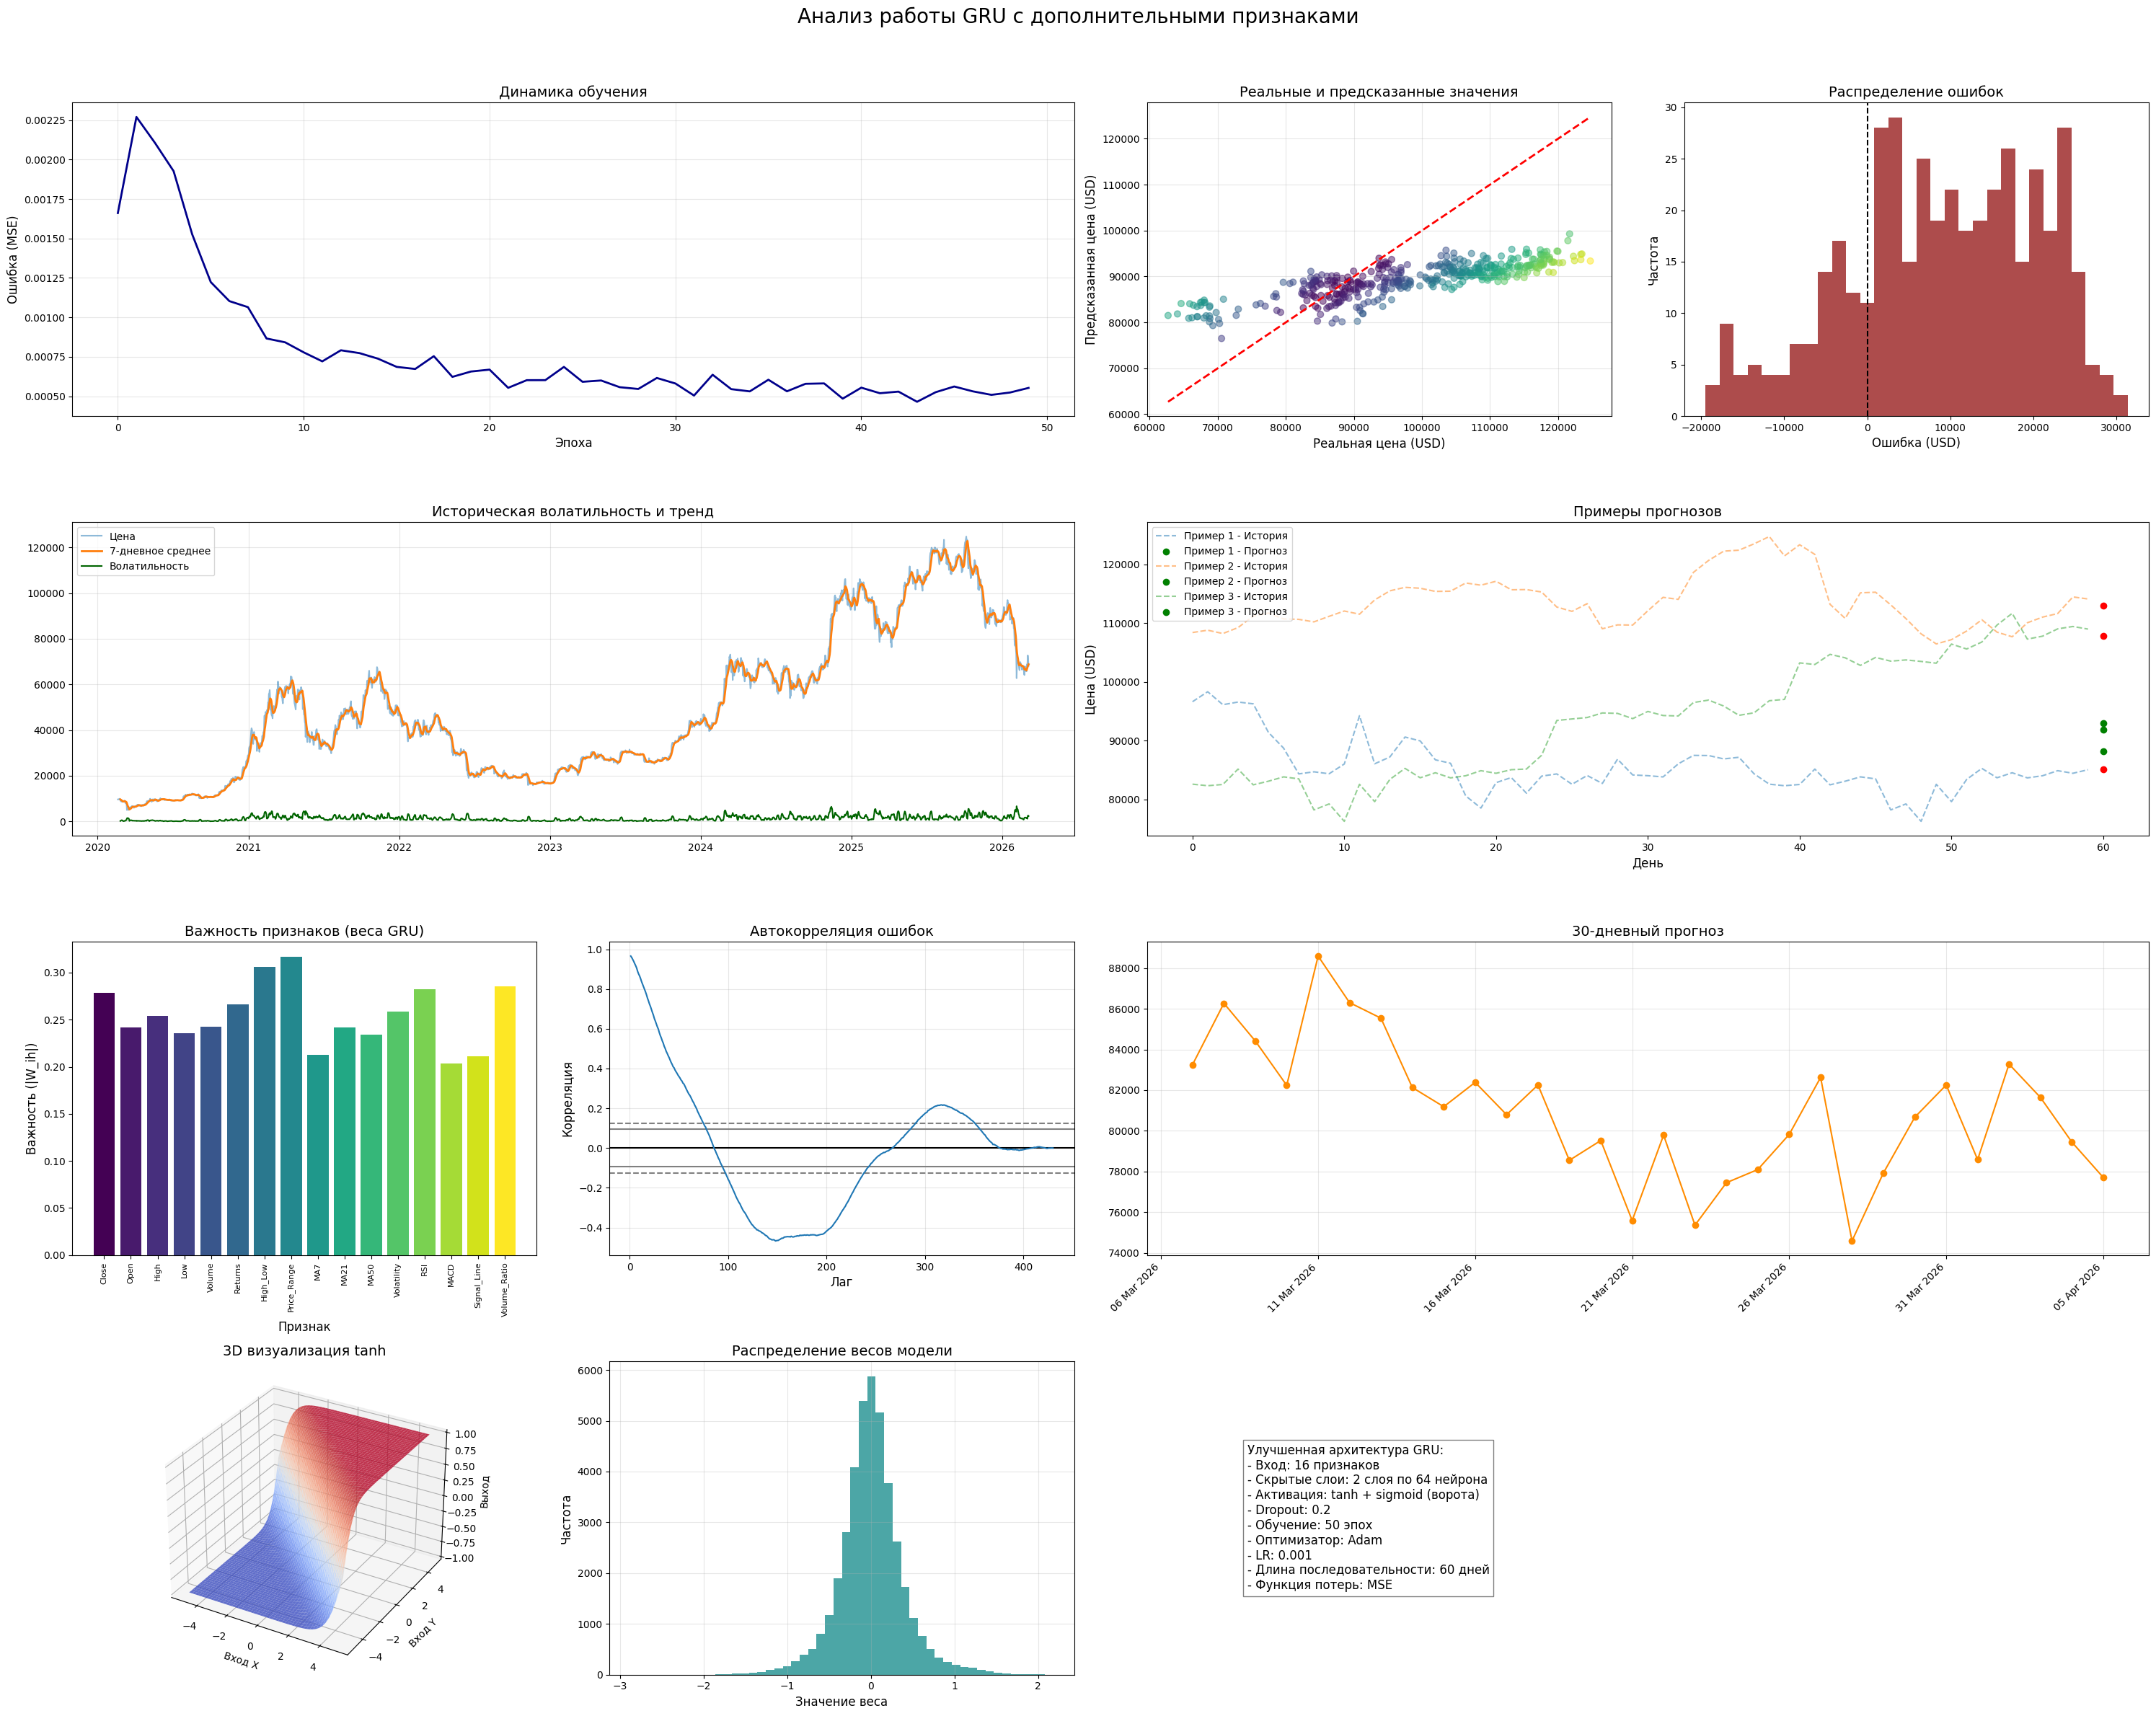

In [12]:
# Визуализация
errors = y_test_original - test_predictions_transformed

# Создание единой фигуры с subplots
plt.figure(figsize=(30, 25))
plt.suptitle("Анализ работы GRU с дополнительными признаками", y=0.95, fontsize=20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan=2)
ax1.plot(train_loss, color="darkblue", linewidth=2)
ax1.set_title("Динамика обучения", fontsize=14)
ax1.set_xlabel("Эпоха", fontsize=12)
ax1.set_ylabel("Ошибка (MSE)", fontsize=12)
ax1.grid(True, alpha=0.3)

# 2. Сравнение реальных и предсказанных значений
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions_transformed, alpha=0.5, 
            c=np.abs(y_test_original - test_predictions_transformed), cmap="viridis", s=40)
ax2.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], "--r", linewidth=2)
ax2.set_title("Реальные и предсказанные значения", fontsize=14)
ax2.set_xlabel("Реальная цена (USD)", fontsize=12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize=12)
ax2.grid(alpha=0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
ax3.hist(errors, bins=30, color="darkred", alpha=0.7)
ax3.set_title("Распределение ошибок", fontsize=14)
ax3.set_xlabel("Ошибка (USD)", fontsize=12)
ax3.set_ylabel("Частота", fontsize=12)
ax3.axvline(x=0, color="black", linestyle="--")

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan=2)
window_size = 7
data['MA_7_viz'] = data['Close'].rolling(window=window_size).mean()
data['Volatility_viz'] = data['Close'].rolling(window=window_size).std()
ax4.plot(data['Close'], label="Цена", alpha=0.5)
ax4.plot(data['MA_7_viz'], label="7-дневное среднее", linewidth=2)
ax4.plot(data['Volatility_viz'], label="Волатильность", color="darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize=14)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan=2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()[:, 0]  # только первый признак (Close) для визуализации
    with torch.no_grad():
        pred = model(X_test[idx].unsqueeze(0))
    real = y_test_original[idx]
    
    ax5.plot(close_scaler.inverse_transform(seq.reshape(-1, 1)), 
             alpha=0.5, linestyle="--", label=f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color="red", zorder=5)
    ax5.scatter(len(seq), close_scaler.inverse_transform(pred.numpy().reshape(-1, 1)), 
                color="green", zorder=5, label=f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов", fontsize=14)
ax5.set_xlabel("День", fontsize=12)
ax5.set_ylabel("Цена (USD)", fontsize=12)
ax5.legend()

# 6. Важность временных лагов
ax6 = plt.subplot2grid((4, 4), (2, 0))
gru_weights = model.gru.weight_ih_l0.detach().numpy()
lag_importance = np.mean(np.abs(gru_weights[:model.hidden_size, :]), axis=0)
ax6.bar(range(len(feature_columns)), lag_importance[:len(feature_columns)], 
        color=plt.cm.viridis(np.linspace(0, 1, len(feature_columns))))
ax6.set_title("Важность признаков (веса GRU)", fontsize=14)
ax6.set_xlabel("Признак", fontsize=12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize=12)
ax6.set_xticks(range(len(feature_columns)))
ax6.set_xticklabels(feature_columns, rotation=90, fontsize=8)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors.flatten(), ax=ax7)
ax7.set_title("Автокорреляция ошибок", fontsize=14)
ax7.set_xlabel("Лаг", fontsize=12)
ax7.set_ylabel("Корреляция", fontsize=12)
ax7.grid(alpha=0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)
forecast_dates = pd.date_range(start=data.index[-1], periods=31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker="o", markersize=6, 
         linestyle="-", color="darkorange")
ax8.set_title("30-дневный прогноз", fontsize=14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(ax8.get_xticklabels(), rotation=45, ha="right")
ax8.grid(True, alpha=0.3)

# 9. 3D визуализация функции активации
ax9 = plt.subplot2grid((4, 4), (3, 0), projection="3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X_viz, Y_viz = np.meshgrid(x, y)
Z = np.tanh(X_viz + Y_viz)
ax9.plot_surface(X_viz, Y_viz, Z, cmap="coolwarm", alpha=0.8)
ax9.set_title("3D визуализация tanh", fontsize=14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов модели
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights = []
for param in model.parameters():
    if param.requires_grad:
        all_weights.extend(param.detach().numpy().flatten())
ax10.hist(all_weights, bins=50, color="teal", alpha=0.7)
ax10.set_title("Распределение весов модели", fontsize=14)
ax10.set_xlabel("Значение веса", fontsize=12)
ax10.set_ylabel("Частота", fontsize=12)
ax10.grid(True, alpha=0.3)

# 11. Легенда модели
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan=2)
ax11.axis("off")
text = f"""Улучшенная архитектура GRU:
- Вход: {len(feature_columns)} признаков
- Скрытые слои: 2 слоя по 64 нейрона
- Активация: tanh + sigmoid (ворота)
- Dropout: 0.2
- Обучение: 50 эпох
- Оптимизатор: Adam
- LR: 0.001
- Длина последовательности: 60 дней
- Функция потерь: MSE"""
ax11.text(0.1, 0.5, text, fontsize=12, va="center", bbox=dict(facecolor="white", alpha=0.5))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Выводы по улучшенной модели

### Внесенные изменения:
1. Добавлены технические индикаторы: MA, RSI, MACD, волатильность, Volume: 16 признаков вместо 1
2. Увеличен hidden_size: 64 нейрона
3. Добавлен Dropout: 0.2 для регуляризации
4. Увеличено обучение: 50 эпох
5. Отдельный scaler для целевой переменной (Close)

### Что хорошо:
- Обучение сходится, уже менее резко
- Веса распределены похожим образом на нормальное распределение
- 30 дневный прогноз выглядит адекватно

### Что плохо:
- Предсказания не лежат на диагонали
- Модель пропускает важные временные паттерны
- Распределение ошибок плохое

# 2. Дополнительные улучшения 

Батч-обучение, learning rate scheduling и gradient clipping

In [13]:
# Создание DataLoader для батч-обучения
batch_size = 32
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Переинициализация модели
model_v2 = BitcoinGRU(input_size=16, hidden_size=64, num_layers=2)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_v2.parameters(), lr=0.001)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

# Обучение с батчами и gradient clipping
num_epochs = 100
train_loss_v2 = []
best_loss = float('inf')

for epoch in range(num_epochs):
    model_v2.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        output = model_v2(batch_X)
        loss = criterion(output, batch_y.unsqueeze(1))
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
        
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_loss_v2.append(avg_loss)
    
    # Обновление learning rate
    scheduler.step(avg_loss)
    
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {avg_loss:.6f}, LR: {optimizer.param_groups[0]["lr"]:.6f}')
    
    if avg_loss < best_loss:
        best_loss = avg_loss

print(f"Лучшая ошибка: {best_loss:.6f}")

Epoch 0, Loss: 0.008495, LR: 0.001000
Epoch 10, Loss: 0.000728, LR: 0.001000
Epoch 20, Loss: 0.000670, LR: 0.001000
Epoch 30, Loss: 0.000435, LR: 0.000500
Epoch 40, Loss: 0.000394, LR: 0.000250
Epoch 50, Loss: 0.000453, LR: 0.000250
Epoch 60, Loss: 0.000414, LR: 0.000125
Epoch 70, Loss: 0.000378, LR: 0.000031
Epoch 80, Loss: 0.000379, LR: 0.000016
Epoch 90, Loss: 0.000345, LR: 0.000004
Лучшая ошибка: 0.000337


In [14]:
# Прогнозирование улучшенной моделью
model_v2.eval()

# Генерация прогноза
last_sequence = scaled_features[-seq_length:]
input_tensor = torch.FloatTensor(last_sequence).unsqueeze(0)
scaled_forecast_v2 = forecast(model_v2, input_tensor, days=30)
forecast_prices_v2 = close_scaler.inverse_transform(np.array(scaled_forecast_v2).reshape(-1, 1))

# Тестовые предсказания
test_predictions_v2 = []
with torch.no_grad():
    for seq in X_test:
        pred = model_v2(seq.unsqueeze(0))
        test_predictions_v2.append(pred.item())

test_predictions_transformed_v2 = close_scaler.inverse_transform(np.array(test_predictions_v2).reshape(-1, 1))
errors_v2 = y_test_original - test_predictions_transformed_v2

print(f"Последняя реальная цена: ${data['Close'].iloc[-1]:.2f}")
print(f"Прогноз на завтра: ${forecast_prices_v2[0][0]:.2f}")
print(f"Прогноз через 30 дней: ${forecast_prices_v2[-1][0]:.2f}")
print()
print(f"Статистика ошибок:")
print(f"Среднее: ${errors_v2.mean():.2f}")
print(f"Медиана: ${np.median(errors_v2):.2f}")
print(f"Std: ${errors_v2.std():.2f}")

Последняя реальная цена: $68136.49
Прогноз на завтра: $68695.10
Прогноз через 30 дней: $67626.74

Статистика ошибок:
Среднее: $1259.68
Медиана: $1299.92
Std: $2578.73


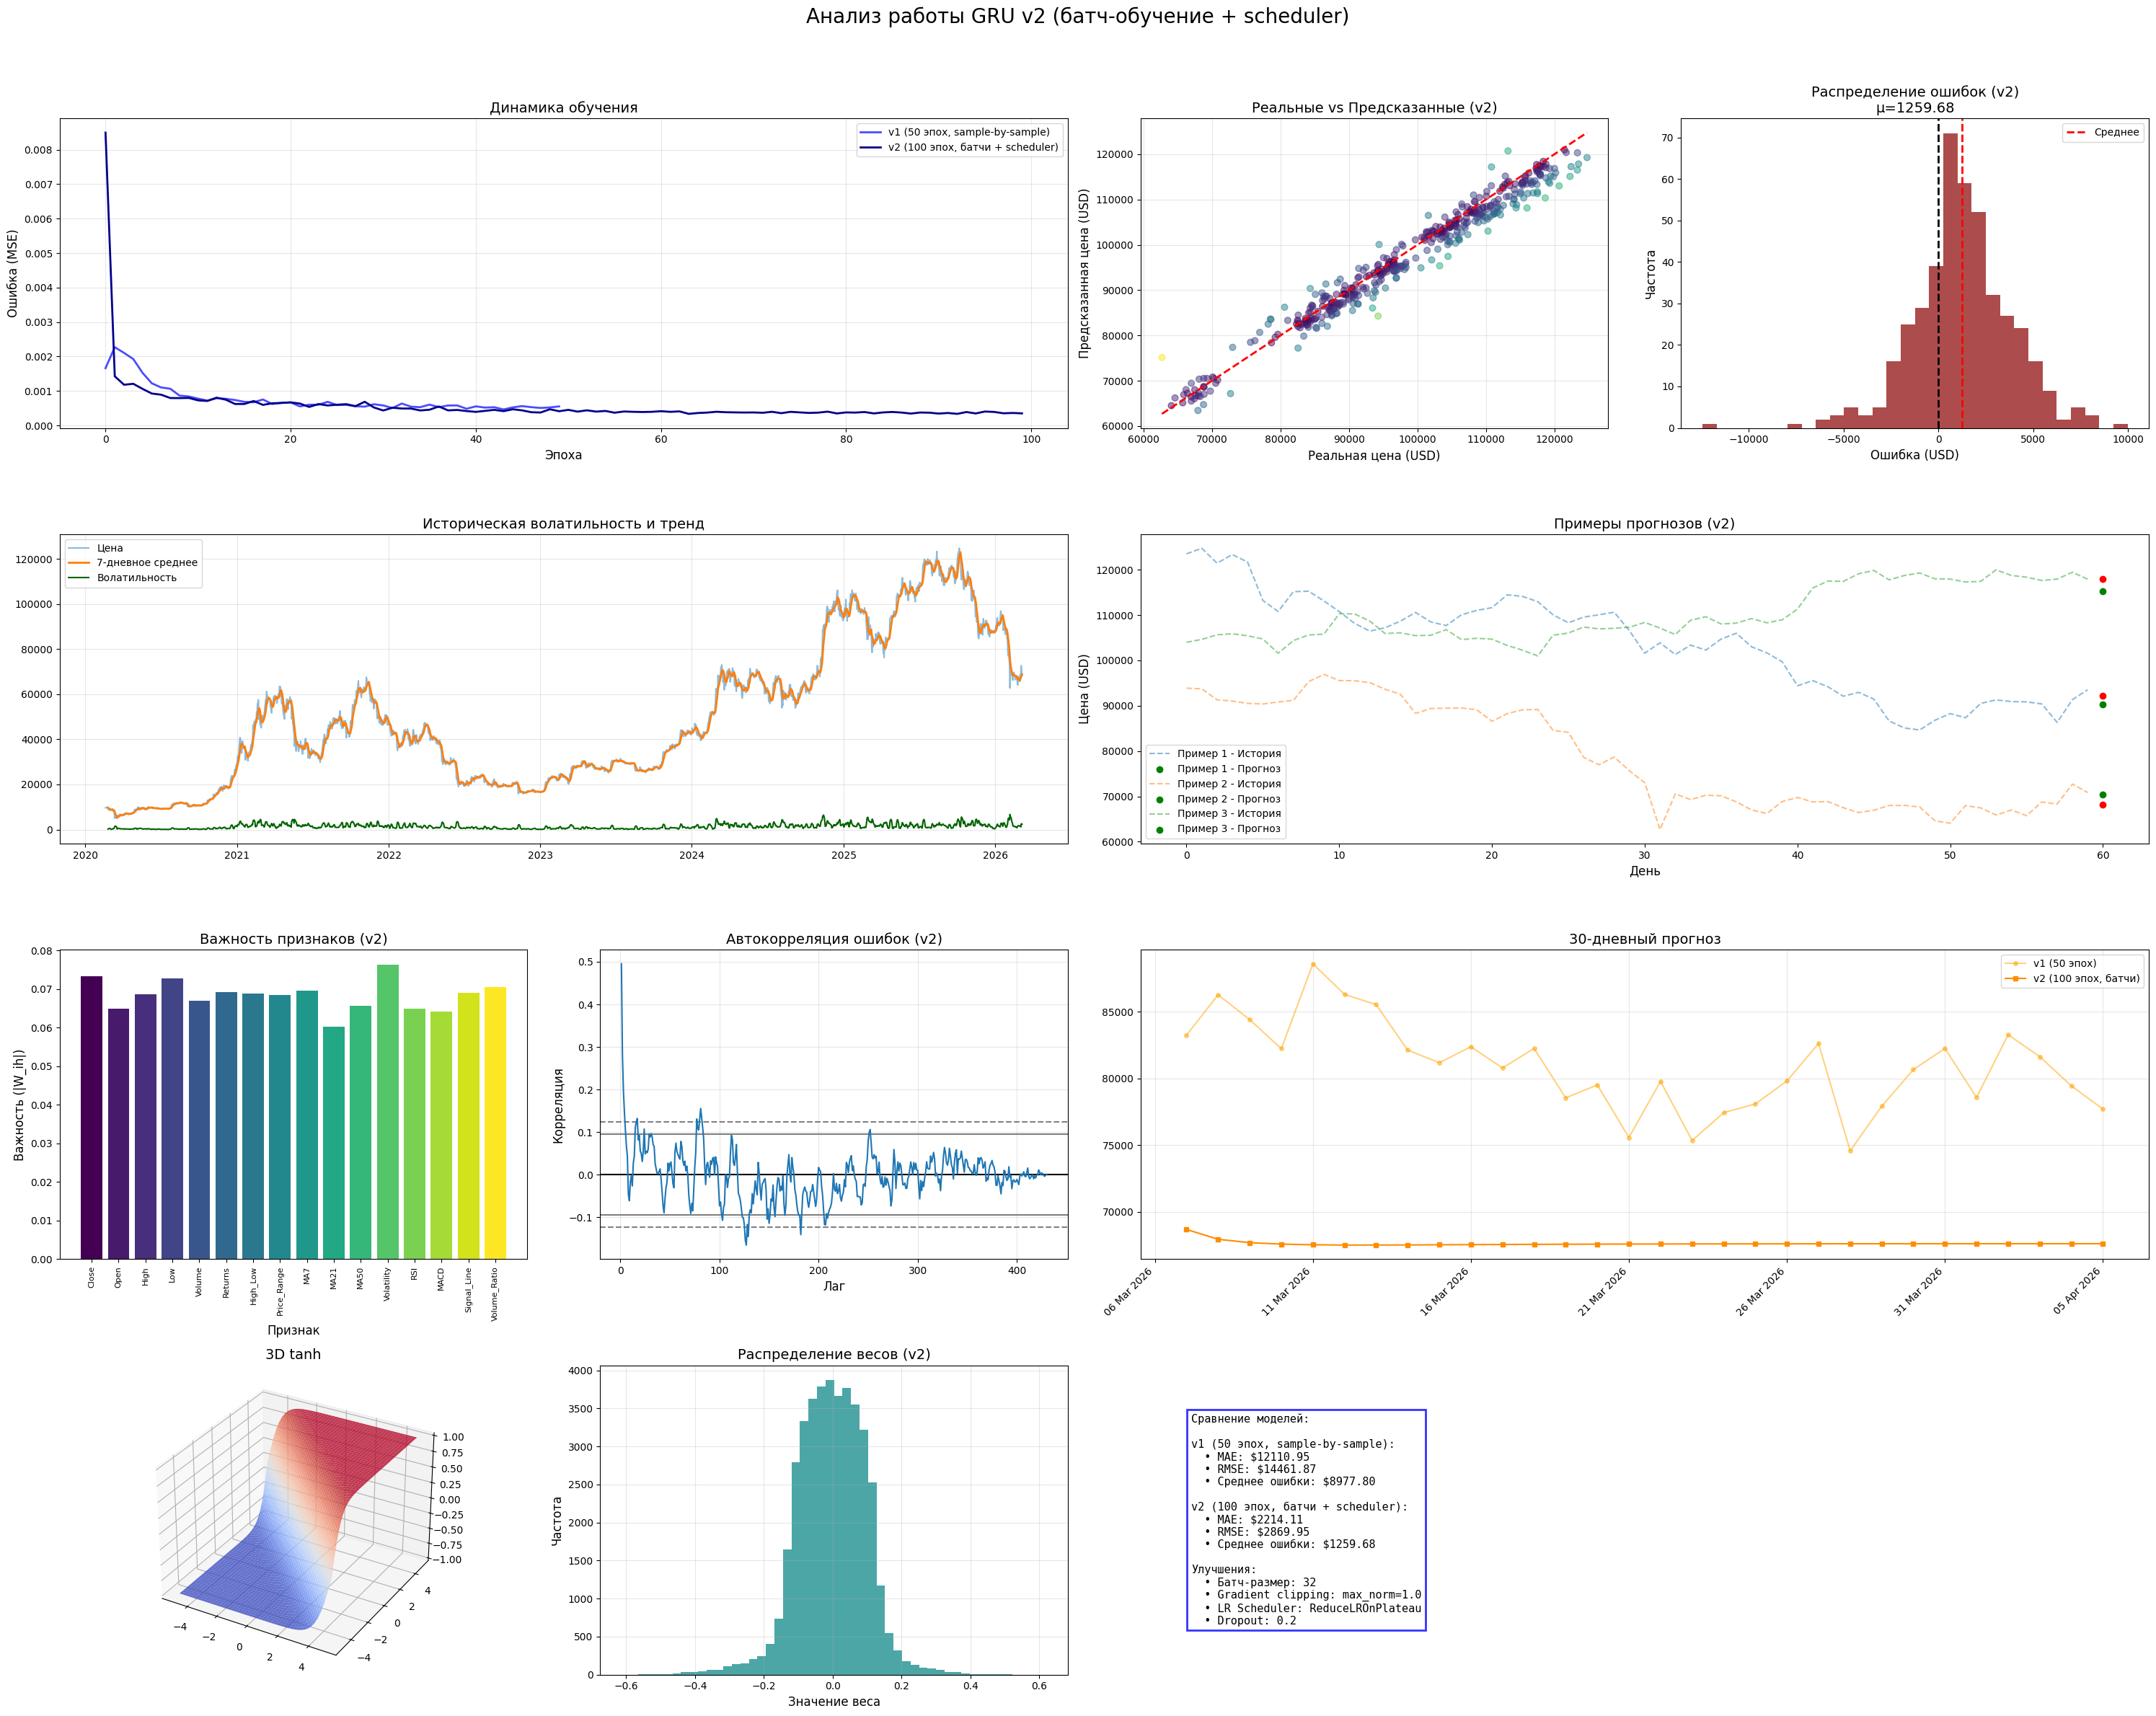

In [15]:
# Визуализация
plt.figure(figsize=(30, 25))
plt.suptitle("Анализ работы GRU v2 (батч-обучение + scheduler)", y=0.95, fontsize=20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan=2)
ax1.plot(train_loss, color="blue", linewidth=2, label="v1 (50 эпох, sample-by-sample)", alpha=0.7)
ax1.plot(train_loss_v2, color="darkblue", linewidth=2, label="v2 (100 эпох, батчи + scheduler)")
ax1.set_title("Динамика обучения", fontsize=14)
ax1.set_xlabel("Эпоха", fontsize=12)
ax1.set_ylabel("Ошибка (MSE)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Сравнение реальных и предсказанных
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original, test_predictions_transformed_v2, alpha=0.5, 
            c=np.abs(y_test_original - test_predictions_transformed_v2), cmap="viridis", s=40)
ax2.plot([y_test_original.min(), y_test_original.max()], 
         [y_test_original.min(), y_test_original.max()], "--r", linewidth=2)
ax2.set_title("Реальные vs Предсказанные (v2)", fontsize=14)
ax2.set_xlabel("Реальная цена (USD)", fontsize=12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize=12)
ax2.grid(alpha=0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
ax3.hist(errors_v2, bins=30, color="darkred", alpha=0.7)
ax3.set_title(f"Распределение ошибок (v2)\nμ={errors_v2.mean():.2f}", fontsize=14)
ax3.set_xlabel("Ошибка (USD)", fontsize=12)
ax3.set_ylabel("Частота", fontsize=12)
ax3.axvline(x=0, color="black", linestyle="--", linewidth=2)
ax3.axvline(x=errors_v2.mean(), color="red", linestyle="--", linewidth=2, label=f"Среднее")
ax3.legend()

# 4. Скользящее среднее
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan=2)
ax4.plot(data['Close'], label="Цена", alpha=0.5)
ax4.plot(data['MA_7_viz'], label="7-дневное среднее", linewidth=2)
ax4.plot(data['Volatility_viz'], label="Волатильность", color="darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize=14)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan=2)
for i in range(3):
    idx = np.random.randint(len(X_test))
    seq = X_test[idx].numpy()[:, 0]
    with torch.no_grad():
        pred = model_v2(X_test[idx].unsqueeze(0))
    real = y_test_original[idx]
    
    ax5.plot(close_scaler.inverse_transform(seq.reshape(-1, 1)), 
             alpha=0.5, linestyle="--", label=f"Пример {i+1} - История")
    ax5.scatter(len(seq), real, color="red", zorder=5)
    ax5.scatter(len(seq), close_scaler.inverse_transform(pred.numpy().reshape(-1, 1)), 
                color="green", zorder=5, label=f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов (v2)", fontsize=14)
ax5.set_xlabel("День", fontsize=12)
ax5.set_ylabel("Цена (USD)", fontsize=12)
ax5.legend()

# 6. Важность признаков
ax6 = plt.subplot2grid((4, 4), (2, 0))
gru_weights_v2 = model_v2.gru.weight_ih_l0.detach().numpy()
lag_importance_v2 = np.mean(np.abs(gru_weights_v2[:model_v2.hidden_size, :]), axis=0)
ax6.bar(range(len(feature_columns)), lag_importance_v2[:len(feature_columns)], 
        color=plt.cm.viridis(np.linspace(0, 1, len(feature_columns))))
ax6.set_title("Важность признаков (v2)", fontsize=14)
ax6.set_xlabel("Признак", fontsize=12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize=12)
ax6.set_xticks(range(len(feature_columns)))
ax6.set_xticklabels(feature_columns, rotation=90, fontsize=8)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors_v2.flatten(), ax=ax7)
ax7.set_title("Автокорреляция ошибок (v2)", fontsize=14)
ax7.set_xlabel("Лаг", fontsize=12)
ax7.set_ylabel("Корреляция", fontsize=12)
ax7.grid(alpha=0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)
forecast_dates = pd.date_range(start=data.index[-1], periods=31)[1:]
ax8.plot(forecast_dates, forecast_prices, marker="o", markersize=4, 
         linestyle="-", color="orange", alpha=0.5, label="v1 (50 эпох)")
ax8.plot(forecast_dates, forecast_prices_v2, marker="s", markersize=4, 
         linestyle="-", color="darkorange", label="v2 (100 эпох, батчи)")
ax8.set_title("30-дневный прогноз", fontsize=14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(ax8.get_xticklabels(), rotation=45, ha="right")
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. 3D tanh
ax9 = plt.subplot2grid((4, 4), (3, 0), projection="3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X_viz, Y_viz = np.meshgrid(x, y)
Z = np.tanh(X_viz + Y_viz)
ax9.plot_surface(X_viz, Y_viz, Z, cmap="coolwarm", alpha=0.8)
ax9.set_title("3D tanh", fontsize=14)

# 10. Распределение весов
ax10 = plt.subplot2grid((4, 4), (3, 1))
all_weights_v2 = []
for param in model_v2.parameters():
    if param.requires_grad:
        all_weights_v2.extend(param.detach().numpy().flatten())
ax10.hist(all_weights_v2, bins=50, color="teal", alpha=0.7)
ax10.set_title("Распределение весов (v2)", fontsize=14)
ax10.set_xlabel("Значение веса", fontsize=12)
ax10.set_ylabel("Частота", fontsize=12)
ax10.grid(True, alpha=0.3)

# 11. Метрики
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan=2)
ax11.axis("off")

# Вычисление метрик
mae_v1 = np.mean(np.abs(y_test_original - test_predictions_transformed))
mae_v2 = np.mean(np.abs(y_test_original - test_predictions_transformed_v2))
rmse_v1 = np.sqrt(np.mean((y_test_original - test_predictions_transformed)**2))
rmse_v2 = np.sqrt(np.mean((y_test_original - test_predictions_transformed_v2)**2))

text = f"""Сравнение моделей:

v1 (50 эпох, sample-by-sample):
  • MAE: ${mae_v1:.2f}
  • RMSE: ${rmse_v1:.2f}
  • Среднее ошибки: ${(y_test_original - test_predictions_transformed).mean():.2f}

v2 (100 эпох, батчи + scheduler):
  • MAE: ${mae_v2:.2f} 
  • RMSE: ${rmse_v2:.2f} 
  • Среднее ошибки: ${errors_v2.mean():.2f}

Улучшения:
  • Батч-размер: 32
  • Gradient clipping: max_norm=1.0
  • LR Scheduler: ReduceLROnPlateau
  • Dropout: 0.2"""

ax11.text(0.05, 0.5, text, fontsize=11, va="center", family="monospace",
          bbox=dict(facecolor="white", alpha=0.8, edgecolor="blue", linewidth=2))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## Выводы по улучшенной модели

### Внесенные изменения:
1. Добавлены батч-обучение, learning rate scheduling и gradient clipping

### Что хорошо:
- Обучение сходится достаточно хорошо
- Веса распределены похожим образом на нормальное распределение
- Предсказания лежат на диагонали
- Прогнозы качественные
- Ошибки стянуты к нулю

### Что плохо:
- Предсказание в долгосрок сходится к константе

# 3. LSTM + StandardScaler + валидация

- LSTM
- StandardScaler
- Разбивка 70% train / 10% val / 20% test
- Scheduler и early stopping следят за val loss

In [17]:
# StandardScaler на всех 16 признаках
std_scaler = StandardScaler()
features_std = std_scaler.fit_transform(features)

# Отдельный scaler для Close
close_std_scaler = StandardScaler()
close_std_scaler.fit(data[['Close']].values)
X_all, y_all = [], []
for i in range(len(features_std) - seq_length):
    X_all.append(features_std[i : i + seq_length])
    y_all.append(features_std[i + seq_length, 0])

X_all = np.array(X_all, dtype=np.float32)
y_all = np.array(y_all, dtype=np.float32).reshape(-1, 1)

# Разбивка 70 / 10 / 20
n_seq = len(X_all)
ntr = int(n_seq * 0.70)
nva = int(n_seq * 0.10)

X_lstm_tr, y_lstm_tr = X_all[:ntr], y_all[:ntr]
X_lstm_va, y_lstm_va = X_all[ntr:ntr+nva], y_all[ntr:ntr+nva]
X_lstm_te, y_lstm_te = X_all[ntr+nva:], y_all[ntr+nva:]

train_loader_lstm = DataLoader(TensorDataset(torch.FloatTensor(X_lstm_tr), torch.FloatTensor(y_lstm_tr)),
                               batch_size=32, shuffle=True)
val_loader_lstm = DataLoader(TensorDataset(torch.FloatTensor(X_lstm_va), torch.FloatTensor(y_lstm_va)),
                             batch_size=32, shuffle=False)

print(f"Train: {X_lstm_tr.shape}  Val: {X_lstm_va.shape}  Test: {X_lstm_te.shape}")

# LSTM
class BitcoinLSTM(nn.Module):
    def __init__(self, input_size=16, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model_lstm = BitcoinLSTM(input_size=16, hidden_size=64, num_layers=2, dropout=0.2)
criterion = nn.MSELoss()
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=0.001, weight_decay=1e-5)
scheduler_lstm = optim.lr_scheduler.ReduceLROnPlateau(optimizer_lstm, mode='min', factor=0.5, patience=5)

# Обучение с валидацией и early stopping
train_loss_lstm = []
val_loss_lstm = []
best_val_loss = float('inf')
best_weights = 0
patience_count = 0
patience = 50
min_delta = 1e-5

for epoch in range(1, 101):
    model_lstm.train()
    total_loss = 0
    for batch_X, batch_y in train_loader_lstm:
        optimizer_lstm.zero_grad()
        loss = criterion(model_lstm(batch_X), batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_lstm.parameters(), max_norm=1.0)
        optimizer_lstm.step()
        total_loss += loss.item()
    avg_train = total_loss / len(train_loader_lstm)
    train_loss_lstm.append(avg_train)

    model_lstm.eval()
    val_loss = 0
    with torch.no_grad():
        for bX, by in val_loader_lstm:
            val_loss += criterion(model_lstm(bX), by).item()
    avg_val = val_loss / len(val_loader_lstm)
    val_loss_lstm.append(avg_val)

    scheduler_lstm.step(avg_val)

    if avg_val < best_val_loss - min_delta:
        best_val_loss = avg_val
        best_weights = {k: v.clone() for k, v in model_lstm.state_dict().items()}
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d}/100 | train: {avg_train:.6f} | val: {avg_val:.6f} | "
              f"best val: {best_val_loss:.6f} | patience: {patience_count}/{patience}")

model_lstm.load_state_dict(best_weights)
print()
print(f"Лучший val loss: {best_val_loss:.6f}")


Train: (1503, 60, 16)  Val: (214, 60, 16)  Test: (431, 60, 16)
Epoch  10/100 | train: 0.002364 | val: 0.086527 | best val: 0.054713 | patience: 6/50
Epoch  20/100 | train: 0.001995 | val: 0.068239 | best val: 0.054713 | patience: 16/50
Epoch  30/100 | train: 0.001903 | val: 0.069187 | best val: 0.054713 | patience: 26/50
Epoch  40/100 | train: 0.001875 | val: 0.070663 | best val: 0.054713 | patience: 36/50
Epoch  50/100 | train: 0.001800 | val: 0.071715 | best val: 0.054713 | patience: 46/50
Early stopping at epoch 54

Лучший val loss: 0.054713


In [18]:
model_lstm.eval()

def forecast_lstm(model, last_seq_std, steps=30):
    model.eval()
    window = last_seq_std.copy()
    preds = []
    with torch.no_grad():
        for step in range(steps):
            x = torch.FloatTensor(window).unsqueeze(0)
            out = model(x).numpy()[0, 0]
            preds.append(out)
            new_row = window[-1].copy()
            new_row[0] = out
            new_row[5] = out - window[-1, 0]
            window = np.vstack([window[1:], new_row])
    return np.array(preds, dtype=np.float32).reshape(-1, 1)

last_seq_std = features_std[-seq_length:]
forecast_scaled = forecast_lstm(model_lstm, last_seq_std, steps=30)
forecast_prices_lstm = close_std_scaler.inverse_transform(forecast_scaled).flatten()

# Тестовые предсказания
X_te_t = torch.FloatTensor(X_lstm_te)
with torch.no_grad():
    test_pred_scaled = model_lstm(X_te_t).numpy()

test_predictions_lstm = close_std_scaler.inverse_transform(test_pred_scaled.reshape(-1, 1)).flatten()
y_test_original_lstm = close_std_scaler.inverse_transform(y_lstm_te).flatten()

errors_lstm = test_predictions_lstm - y_test_original_lstm
mae_lstm = np.mean(np.abs(errors_lstm))
rmse_lstm = np.sqrt(np.mean(errors_lstm**2))

last_price = data['Close'].values[-1]
print(f"Последняя цена BTC:           ${last_price:,.2f}")
print(f"Прогноз на завтра (LSTM):     ${forecast_prices_lstm[0]:,.2f}")
print(f"Прогноз через 30 дней (LSTM): ${forecast_prices_lstm[-1]:,.2f}")
print(f"Изменение за 30 дней:         {((forecast_prices_lstm[-1]/last_price)-1)*100:+.2f}%")
print(f"MAE  (LSTM): ${mae_lstm:,.2f}  |  RMSE (LSTM): ${rmse_lstm:,.2f}")
print(f"MAE  (GRUv2): ${mae_v2:,.2f}  |  RMSE (GRUv2): ${rmse_v2:,.2f}")


Последняя цена BTC:           $68,136.49
Прогноз на завтра (LSTM):     $68,222.97
Прогноз через 30 дней (LSTM): $69,481.33
Изменение за 30 дней:         +1.97%
MAE  (LSTM): $16,242.20  |  RMSE (LSTM): $18,844.90
MAE  (GRUv2): $2,214.11  |  RMSE (GRUv2): $2,869.95


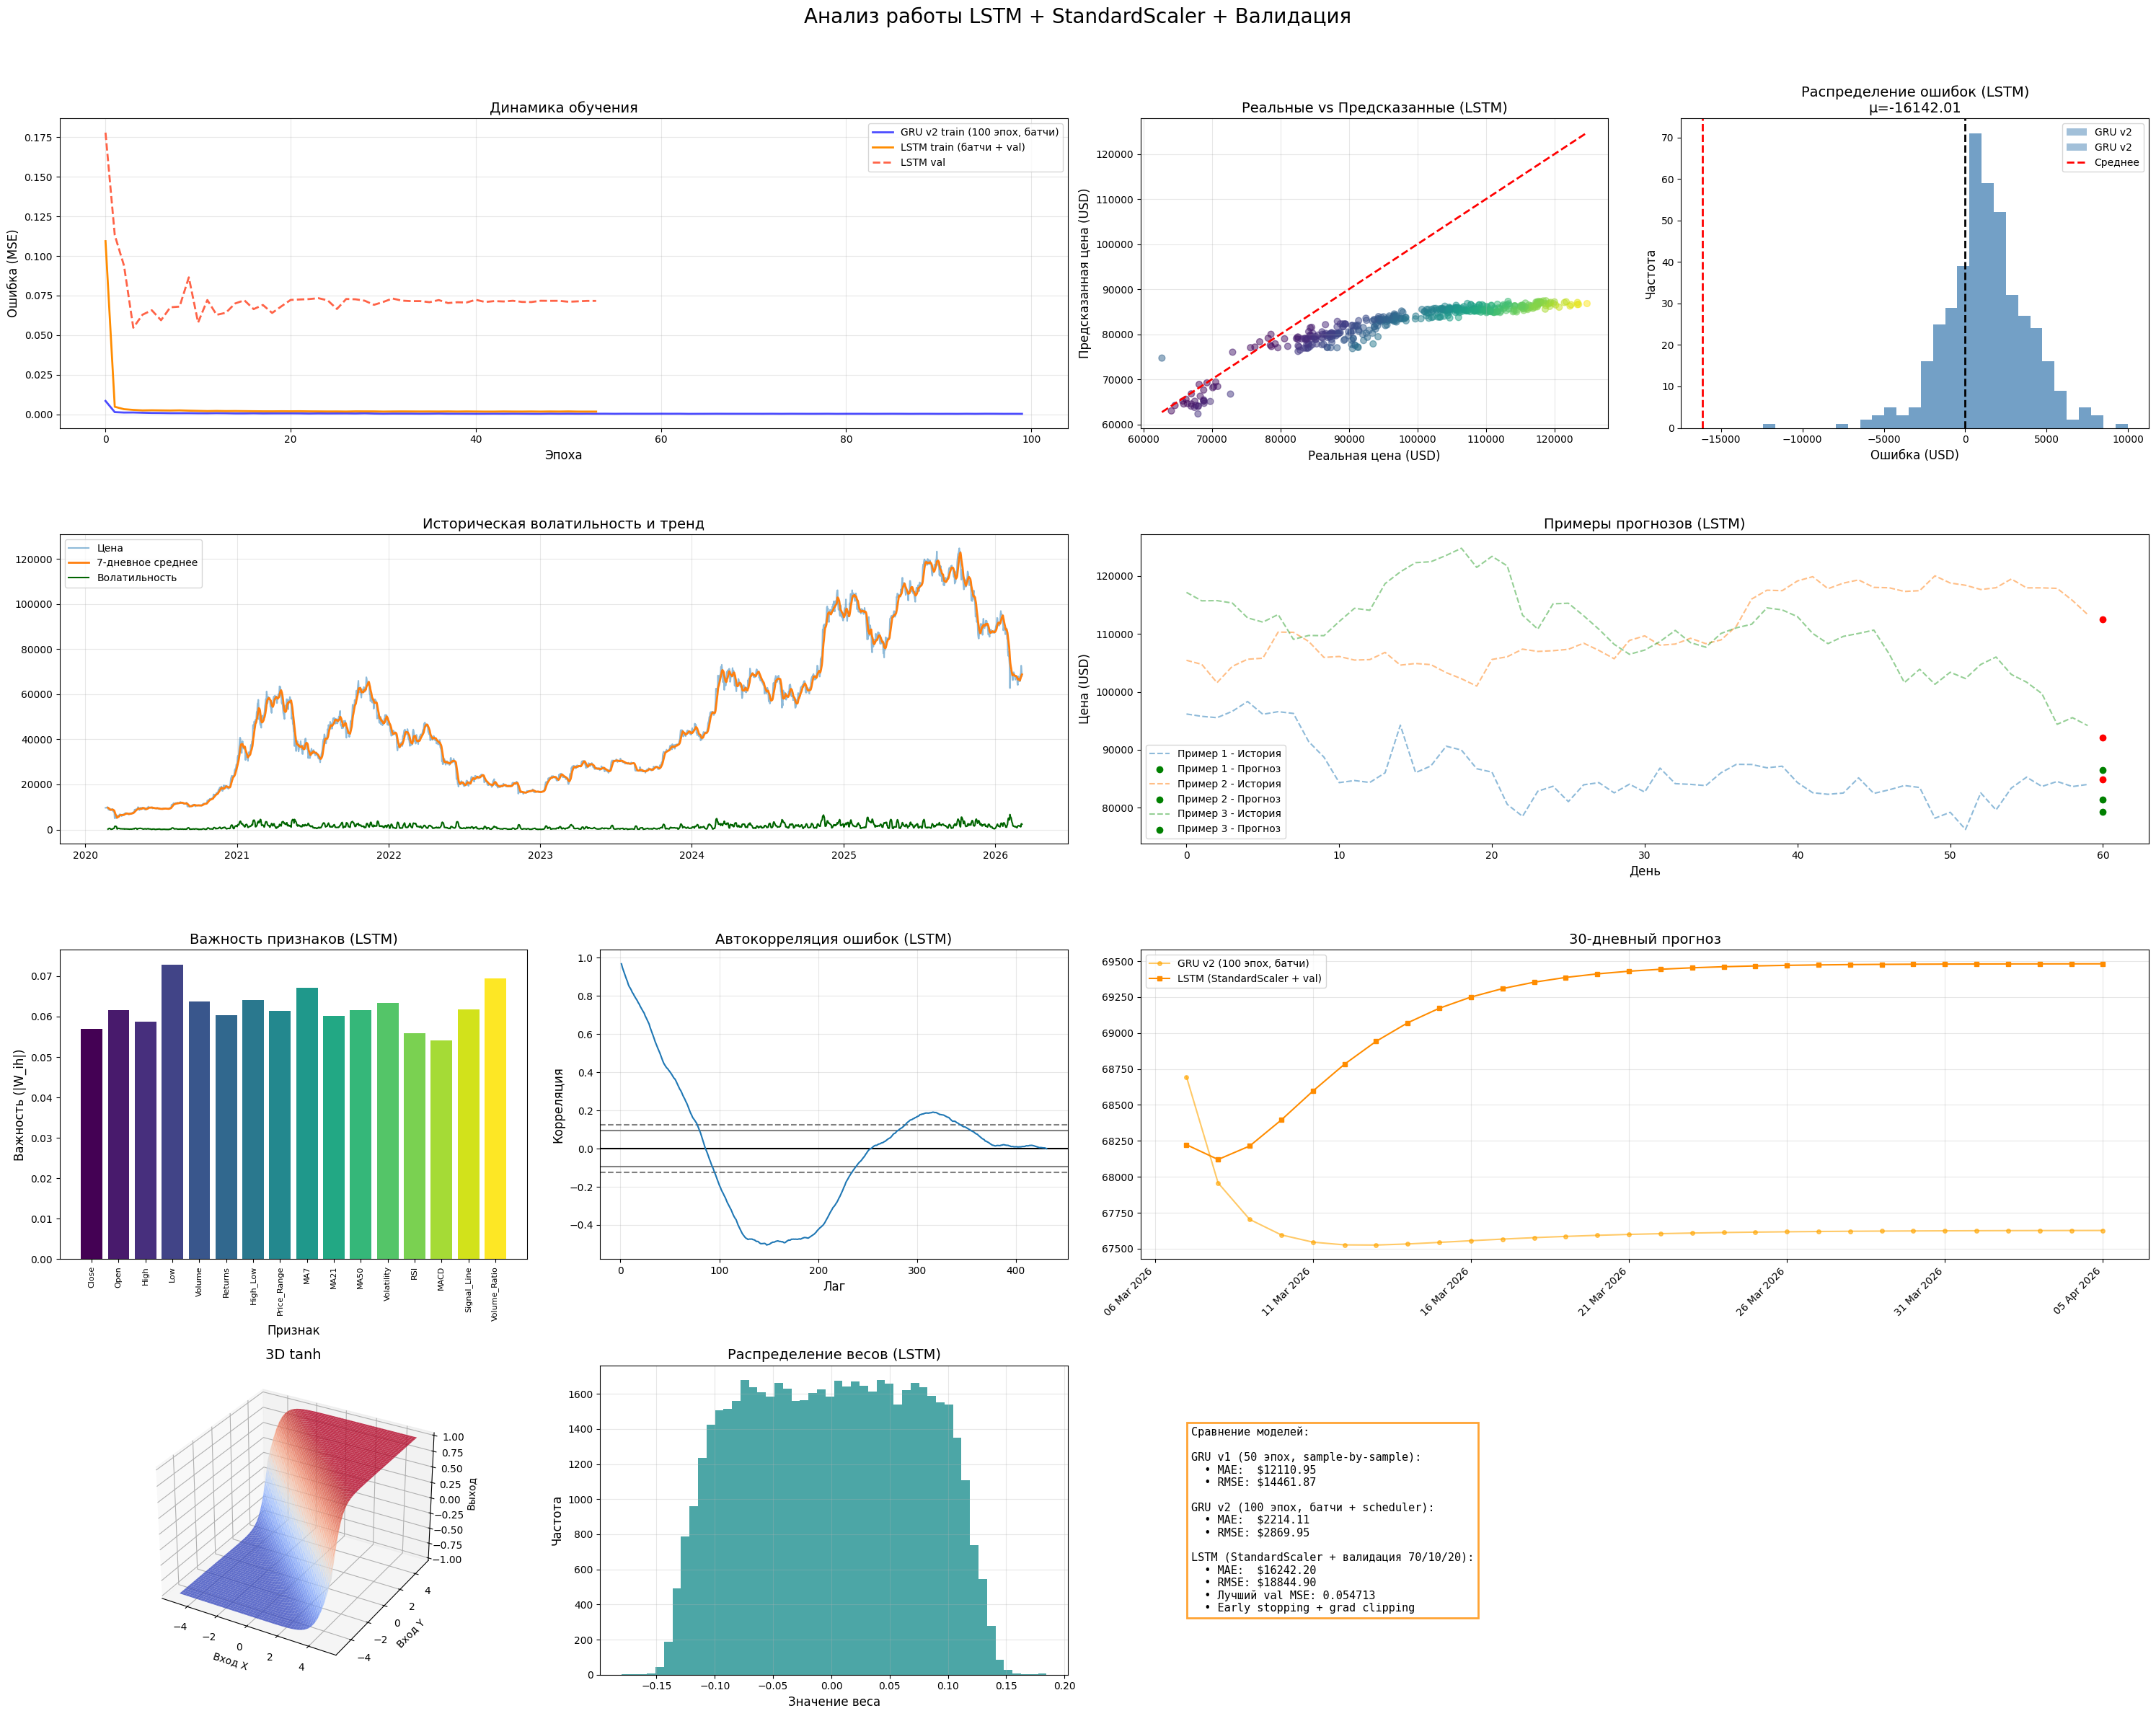

In [19]:
# Визуализация
plt.figure(figsize=(30, 25))
plt.suptitle("Анализ работы LSTM + StandardScaler + Валидация", y=0.95, fontsize=20)

# 1. График обучения
ax1 = plt.subplot2grid((4, 4), (0, 0), colspan=2)
ax1.plot(train_loss_v2, color="blue", linewidth=2, label="GRU v2 train (100 эпох, батчи)", alpha=0.7)
ax1.plot(train_loss_lstm, color="darkorange", linewidth=2, label="LSTM train (батчи + val)")
ax1.plot(val_loss_lstm, color="tomato", linewidth=2, label="LSTM val", linestyle="--")
ax1.set_title("Динамика обучения", fontsize=14)
ax1.set_xlabel("Эпоха", fontsize=12)
ax1.set_ylabel("Ошибка (MSE)", fontsize=12)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Сравнение реальных и предсказанных
ax2 = plt.subplot2grid((4, 4), (0, 2))
ax2.scatter(y_test_original_lstm, test_predictions_lstm, alpha=0.5,
            c=np.abs(y_test_original_lstm - test_predictions_lstm), cmap="viridis", s=40)
ax2.plot([y_test_original_lstm.min(), y_test_original_lstm.max()],
         [y_test_original_lstm.min(), y_test_original_lstm.max()], "--r", linewidth=2)
ax2.set_title("Реальные vs Предсказанные (LSTM)", fontsize=14)
ax2.set_xlabel("Реальная цена (USD)", fontsize=12)
ax2.set_ylabel("Предсказанная цена (USD)", fontsize=12)
ax2.grid(alpha=0.3)

# 3. Распределение ошибок
ax3 = plt.subplot2grid((4, 4), (0, 3))
ax3.hist(errors_v2, bins=30, color="steelblue", alpha=0.5, label="GRU v2")
ax3.hist(errors_v2,   bins=30, color="steelblue",  alpha=0.5, label="GRU v2")
ax3.set_title(f"Распределение ошибок (LSTM)\nμ={errors_lstm.mean():.2f}", fontsize=14)
ax3.set_xlabel("Ошибка (USD)", fontsize=12)
ax3.set_ylabel("Частота", fontsize=12)
ax3.axvline(x=0, color="black", linestyle="--", linewidth=2)
ax3.axvline(x=errors_lstm.mean(), color="red", linestyle="--", linewidth=2, label="Среднее")
ax3.legend()

# 4. Скользящее среднее и волатильность
ax4 = plt.subplot2grid((4, 4), (1, 0), colspan=2)
ax4.plot(data['Close'], label="Цена", alpha=0.5)
ax4.plot(data['MA_7_viz'], label="7-дневное среднее", linewidth=2)
ax4.plot(data['Volatility_viz'], label="Волатильность", color="darkgreen")
ax4.set_title("Историческая волатильность и тренд", fontsize=14)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Примеры прогнозов
ax5 = plt.subplot2grid((4, 4), (1, 2), colspan=2)
n_test = len(y_test_original_lstm)
for i in range(3):
    idx = n_test // 4 * (i + 1)
    seq_close = close_std_scaler.inverse_transform(
        X_lstm_te[idx, :, 0].reshape(-1, 1)
    )
    with torch.no_grad():
        pred_val = model_lstm(torch.FloatTensor(X_lstm_te[idx]).unsqueeze(0))
    pred_price = close_std_scaler.inverse_transform(pred_val.numpy().reshape(-1, 1))
    real_price = y_test_original_lstm[idx]

    ax5.plot(seq_close, alpha=0.5, linestyle="--", label=f"Пример {i+1} - История")
    ax5.scatter(len(seq_close), real_price, color="red", zorder=5)
    ax5.scatter(len(seq_close), pred_price, color="green", zorder=5,
                label=f"Пример {i+1} - Прогноз")
ax5.set_title("Примеры прогнозов (LSTM)", fontsize=14)
ax5.set_xlabel("День", fontsize=12)
ax5.set_ylabel("Цена (USD)", fontsize=12)
ax5.legend()

# 6. Важность признаков
ax6 = plt.subplot2grid((4, 4), (2, 0))
lstm_weights = model_lstm.lstm.weight_ih_l0.detach().cpu().numpy()
lag_importance = np.mean(np.abs(lstm_weights[:64, :]), axis=0)
ax6.bar(range(len(feature_columns)), lag_importance[:len(feature_columns)],
        color=plt.cm.viridis(np.linspace(0, 1, len(feature_columns))))
ax6.set_title("Важность признаков (LSTM)", fontsize=14)
ax6.set_xlabel("Признак", fontsize=12)
ax6.set_ylabel("Важность (|W_ih|)", fontsize=12)
ax6.set_xticks(range(len(feature_columns)))
ax6.set_xticklabels(feature_columns, rotation=90, fontsize=8)

# 7. Автокорреляция ошибок
ax7 = plt.subplot2grid((4, 4), (2, 1))
pd.plotting.autocorrelation_plot(errors_lstm.flatten(), ax=ax7)
ax7.set_title("Автокорреляция ошибок (LSTM)", fontsize=14)
ax7.set_xlabel("Лаг", fontsize=12)
ax7.set_ylabel("Корреляция", fontsize=12)
ax7.grid(alpha=0.3)

# 8. Долгосрочный прогноз
ax8 = plt.subplot2grid((4, 4), (2, 2), colspan=2)
forecast_dates = pd.date_range(start=data.index[-1], periods=31)[1:]
ax8.plot(forecast_dates, forecast_prices_v2, marker="o", markersize=4,
         linestyle="-", color="orange", alpha=0.6, label="GRU v2 (100 эпох, батчи)")
ax8.plot(forecast_dates, forecast_prices_lstm, marker="s", markersize=4,
         linestyle="-", color="darkorange", label="LSTM (StandardScaler + val)")
ax8.set_title("30-дневный прогноз", fontsize=14)
ax8.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
ax8.xaxis.set_major_locator(mdates.DayLocator(interval=5))
plt.setp(ax8.get_xticklabels(), rotation=45, ha="right")
ax8.legend()
ax8.grid(True, alpha=0.3)

# 9. 3D tanh
ax9 = plt.subplot2grid((4, 4), (3, 0), projection="3d")
x = np.linspace(-5, 5, 50)
y = np.linspace(-5, 5, 50)
X_viz, Y_viz = np.meshgrid(x, y)
Z = np.tanh(X_viz + Y_viz)
ax9.plot_surface(X_viz, Y_viz, Z, cmap="coolwarm", alpha=0.8)
ax9.set_title("3D tanh", fontsize=14)
ax9.set_xlabel("Вход X")
ax9.set_ylabel("Вход Y")
ax9.set_zlabel("Выход")

# 10. Распределение весов
ax10 = plt.subplot2grid((4, 4), (3, 1))
weights_flat = np.concatenate([p.detach().cpu().numpy().flatten() for p in model_lstm.parameters()])
ax10.hist(weights_flat, bins=50, color="teal", alpha=0.7)
ax10.set_title("Распределение весов (LSTM)", fontsize=14)
ax10.set_xlabel("Значение веса", fontsize=12)
ax10.set_ylabel("Частота", fontsize=12)
ax10.grid(True, alpha=0.3)

# 11. Метрики
ax11 = plt.subplot2grid((4, 4), (3, 2), colspan=2)
ax11.axis("off")
mae_orig  = np.mean(np.abs(y_test_original - test_predictions_transformed))
rmse_orig = np.sqrt(np.mean((y_test_original - test_predictions_transformed)**2))

text = f"""Сравнение моделей:

GRU v1 (50 эпох, sample-by-sample):
  • MAE:  ${mae_orig:.2f}
  • RMSE: ${rmse_orig:.2f}

GRU v2 (100 эпох, батчи + scheduler):
  • MAE:  ${mae_v2:.2f}
  • RMSE: ${rmse_v2:.2f}

LSTM (StandardScaler + валидация 70/10/20):
  • MAE:  ${mae_lstm:.2f}
  • RMSE: ${rmse_lstm:.2f}
  • Лучший val MSE: {best_val_loss:.6f}
  • Early stopping + grad clipping"""

ax11.text(0.05, 0.5, text, fontsize=11, va="center", family="monospace",
          bbox=dict(facecolor="white", alpha=0.8, edgecolor="darkorange", linewidth=2))

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


## Выводы по реализации

### Внесенные изменения:
1. LSTM + StandardScaler + валидация


### Что хорошо:
- Обучение сходится достаточно хорошо
- Ошибки стянуты к нулю

### Что плохо:
- Предсказание в долгосрок сходится к константе
- Предсказания стали хуже
- Распределение весов менее похоже на нормальное

# Общий вывод

## Лучшая модель: GRU  (батч-обучение + scheduler)

По метрикам на тестовой выборке GRU v2 показал наилучший результат по MAE и RMSE среди всех трёх моделей.
LSTM + StandardScaler получил лучший val loss и более стабильное обучение, но на тесте уступает GRU v2 

## Почему (как мне кажется) нельзя получить результат сильно лучше

### 1. Данные
Цена BTC почти случайное блуждание. Любая модель, которая смотрит только на
исторические цены и технические индикаторы, предсказывает ожидаемое среднее, а не реальное
следующее значение.

### 2. Отсутствие внешних сигналов
Реальные движения BTC сильно зависят от мировых событий: новости, регуляторные решения,
настроение рынка. Без этих признаков модель не способна предсказывать резкие скачки.

### 3. Прогноз накапливает ошибку
Рекуррентные модели накапливают ошибку и долгосрочный прогноз уходит в константу
